# Allen-Cahn PDE

## Task Incremental Learning

### Experiments nomenclature

`L`[learning_mode]

- learning_mode $\in$ \{$w_1+...+w_k$ | \{$w_1, ..., w_k$\} $\in \mathcal{P}$(\{`pinn`, `out`, `der`, `hes`\})\}

### Experiments location

**AllenCahn**

- **TaskIncrementalLearning**
    - **Output** | **Derivative** | **Hesssian** | **PINN** | Mixed ...
        - **Forget** | 
            - **FromScratch** | **FineTune** (*)
        - **Replay** | **Distill** | **Distill_EWC**
            - **Output** | **Derivative** | **Hesssian** | **PINN** | Mixed ...
                - **FromScratch** | **FineTune** (*)
        - **EWC**
            - **FromScratch** | **FineTune** (*)
    - **Task0**
        - **models0** | ... | **modelsM**
            - **tiral0** | ... | **trialN**
                - model.pth, training stats files

(*):
- **Task1** | ... | **TaskT**
    - **models**
        - **trial0**
            - model.pth, training stats files

In [1]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset
from data_utils import extract_TensorDataset, compute_prediction_difference, compute_prediction, extract_targets, extract_boundary
from plot_utils import plot_loss, plot_loss_comp, plot_model_stats, print_model_info, plot_model_stats_grid, print_model_performances, plot_model_performances, plot_performance_comparison
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from generate import X, U, DU, D2U
# ----------------------------------------------
TRAIN = False
SAVE_PLOTS = True
CROSS_THE_RUBICON = True

PDE = "AllenCahn"
PDE_NAME = "Allen-Cahn"
SEED = 42
ACTUAL_MODE = "PINN"

MEMORY_DISTILL = 1024 #1024
MEMORY_REPLAY_SUPERVISED = 1024
MEMORY_REPLAY = 1024
MEMORY_EWC = 1024

LONG_TERM_MEMORY = True
FINE_TUNING = True

ACTION = "Distill" # "Forget" "Replay" "Distill" "EWC"
REPLAY_MODE = "Residual+Boundary" # "Residual" "Boundary" "Residual+Boundary" "Derivative+Output" "Output" "Derivative" "Hessian"
DISTILL_MODE = "Output+Derivative" # "Output" "Derivative" "Hessian"
EWC_WEIGHT = 1.0
EWC_ALPHA = 1.0

EWC_AUTO_WEIGHTING = False
EWC_WARM_UP = 1
EWC_DECAY = 1.0

N_EPOCHS = 200
N_EPOCHS_TASK0 = N_EPOCHS

SMALL_LR = False
LR_MODE = "CosAnn"#"ExpDec"#
DWA_MODE = "Norm1"
CLIP_GRAD = True
# ----------------------------------------------
if LR_MODE == "ExpDec":
    LR = "_ExpLrDecay"
else:
    LR_MODE = "CosAnn"
    LR = "_CosLrAnnealing"

if LONG_TERM_MEMORY:
    MEMORY = "LongMemory"
else:
    MEMORY = "ShortMemory"
if ACTION == "Forget":
    MEMORY = ""

if ACTION == "Replay":
    DISTILL_MODE = REPLAY_MODE
    
FROM_SCRATCH = not FINE_TUNING

if FINE_TUNING:
    MODE = "FineTune"
else:
    MODE = "FromScratch"

if SMALL_LR:
    LR_SIZE = "SmallLR"
else:
    LR_SIZE = ""
    
if not CLIP_GRAD:
    CLIP = "NoGradClip"
else:
    CLIP = "GradClip"

FORGET, REPLAY, DISTILL, EWC = False, False, False, False
if ACTION == "Forget":
    FORGET = True
    FOLDER = f"Forget/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
elif ACTION == "Replay":
    REPLAY = True
    FOLDER = f"Replay/{DISTILL_MODE}/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
    if ("Residual" in REPLAY_MODE and MEMORY_REPLAY is None) or \
        ("Boundary" in REPLAY_MODE and MEMORY_REPLAY is None) or \
        ("Output" in REPLAY_MODE and MEMORY_REPLAY_SUPERVISED is None) or \
        ("Derivative" in REPLAY_MODE and MEMORY_REPLAY_SUPERVISED is None) or \
        ("Hessian" in REPLAY_MODE and MEMORY_REPLAY_SUPERVISED is None):
        FOLDER = "UnlimitedMemory/" + FOLDER
    else:
        FOLDER = "LimitedMemory/" + FOLDER
elif ACTION == "Distill":
    DISTILL = True
    FOLDER = f"Distill/{DISTILL_MODE}/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
    if MEMORY_DISTILL is None:
        FOLDER = "UnlimitedMemory/" + FOLDER
    else:
        FOLDER = "LimitedMemory/" + FOLDER
elif ACTION == "EWC":
    EWC = True
    if EWC_AUTO_WEIGHTING:
        FOLDER = f"EWC/alpha_{EWC_ALPHA}/weight_auto/warmup{EWC_WARM_UP}_decay{EWC_DECAY}/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
    else:
        FOLDER = f"EWC/alpha_{EWC_ALPHA}/weight_{EWC_WEIGHT}/{MODE}{LR_SIZE}{MEMORY}{N_EPOCHS}"
    if MEMORY_EWC is None:
        FOLDER = "UnlimitedMemory/" + FOLDER
    else:
        FOLDER = "LimitedMemory/" + FOLDER

/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions to work with the A-C dataset

In [2]:
def subsample(
    datasets: List[ConcatDataset],
    n_samples: int,
    seed: int = 42
    ) -> List[ConcatDataset]:
    
    reduced_datasets = []
    last_seed = seed
    for concat_ds in datasets:
        seeds = [last_seed+i for i in range(len(concat_ds))]
        last_seed = seeds[-1]
        reduced_concat_ds = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            indices = indices[:n_samples]
            reduced_cols = [col[indices] for col in ds.tensors]
            reduced_concat_ds.append(TensorDataset(*reduced_cols))
        reduced_datasets.append(ConcatDataset(reduced_concat_ds))
    return reduced_datasets

def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset]) -> ConcatDataset:
    n_snapshots = len(datasets[0].datasets)
    data = [None for _ in range(n_snapshots)]
    for i in range(n_snapshots):
        data[i] = merge_ds([concat_ds.datasets[i] for concat_ds in datasets])
    return ConcatDataset(data)

### Load datasets

In [3]:
full_datasets = torch.load(f"{PDE}/data/full_datasets.pth", weights_only=False).datasets
unlabeled_datasets = torch.load(f"{PDE}/data/unlabeled_datasets.pth", weights_only=False).datasets
dev_datasets = torch.load(f"{PDE}/data/dev_datasets.pth", weights_only=False).datasets
train_datasets = torch.load(f"{PDE}/data/train_datasets.pth", weights_only=False).datasets
val_datasets = torch.load(f"{PDE}/data/val_datasets.pth", weights_only=False).datasets
inter_test_datasets = torch.load(f"{PDE}/data/inter_test_datasets.pth", weights_only=False).datasets
intra_test_datasets = torch.load(f"{PDE}/data/intra_test_datasets.pth", weights_only=False).datasets

n_params = 2 # number of xi_j

n = 4 # param vectors values per (composed) task
n_tasks = int(len(dev_datasets)/n)

train_task = [None for _ in range(n_tasks)]
train_boundary_task = [None for _ in range(n_tasks)]
intra_test_task = [None for _ in range(n_tasks)]
nl_task = [None for _ in range(n_tasks)]

train_task[0] = dev_datasets[0:n]
train_boundary_task[0] = [ConcatDataset([extract_boundary(ds)]) for ds in train_task[0]]
nl_task[0] = unlabeled_datasets[0:n]
intra_test_task[0] = intra_test_datasets[0:n]

for i in range(1, n_tasks):
    train_task[i] = dev_datasets[i*n:(i+1)*n]
    train_boundary_task[i] = [ConcatDataset([extract_boundary(ds)]) for ds in train_task[i]]
    nl_task[i] = unlabeled_datasets[i*n:(i+1)*n]
    intra_test_task[i] = intra_test_datasets[i*n:(i+1)*n]

train_datas = [None for _ in range(n_tasks)]
train_boundary_datas = [None for _ in range(n_tasks)]
intra_test_datas = [None for _ in range(n_tasks)]
nl_datas = [None for _ in range(n_tasks)]

for i in range(0, n_tasks):
    train_datas[i] = prepare_dataset(train_task[i])
    train_boundary_datas[i] = prepare_dataset(train_boundary_task[i])
    nl_datas[i] = prepare_dataset(nl_task[i])
    intra_test_datas[i] = prepare_dataset(intra_test_task[i])

inter_test_data = prepare_dataset(inter_test_datasets)

In [4]:
print(len(train_boundary_datas[0]))
print(len(train_datas[0]))
print(f"{len(train_task)}, {len(train_boundary_task)}, {len(nl_task)}, {len(intra_test_task)}")
print(f"{len(train_datas)}, {len(train_boundary_datas)}, {len(nl_datas)}, {len(intra_test_datas)}")

329
8192
4, 4, 4, 4
4, 4, 4, 4


### Task 1, Task 2, Task 3

In [5]:
if TRAIN:
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task0_{N_EPOCHS_TASK0}/models2"
    checkpoint = torch.load(f"{models_dir}/trial0/model.pth", weights_only=False)
    
    lr_init = checkpoint["lr_init"]
    if SMALL_LR:
        lr_init *= 0.5
    
    actual = {
        "mode": ACTUAL_MODE,
        "time_in_input": checkpoint["time_in_input"],
        "space_in_input": checkpoint["space_in_input"],
        "fourier_features": checkpoint["fourier_features"],
        "pde_params_in_input": checkpoint["pde_params_in_input"],
        "boundary": "LocalFull",
        "monitor_conflicts": True,
        "sys_importance": checkpoint["sys_importance"],
        "bc_importance": checkpoint["bc_importance"],
        "ic_importance": checkpoint["ic_importance"],
        "model": "",
        "train_dataset": "",
        "unlabeled_dataset": "",
        "val_dataset": ""
    }
    unlabeled = {
        "dataset": "",
        "subset": {}
    }
    distill = {
        "mode": "Forgetting",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    ewc = {
        "mode": "Off",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0,
        "weight": EWC_WEIGHT,
        "auto_weighting": EWC_AUTO_WEIGHTING,
        "warm_up": EWC_WARM_UP,
        "decay": EWC_DECAY,
        "src_fisher_diag": "",
        "dst_fisher_diag": "",
        "moving_avg_factor": EWC_ALPHA
    }
    dwa = {
        "mode": DWA_MODE,
        "moving_avg_factor": 0.9,
        "moving_avg_frequency": 1,
        "warm_up": 3
    }
    config_dict = {
        "PDE": PDE_NAME,
        "Actual": actual,
        "Unlabeled": unlabeled,
        "Distillation": distill,
        "EWC": ewc,
        "DWA": dwa,
        "pruner": "median",
        "n_warmup_steps": 1000,
        "threshold": 1.0,
        "n_trials": 1,
        "epochs": N_EPOCHS,
        "eval_every": 1,
        "seed": SEED,
        "device": "cpu",
        "learning_rate": lr_init,
        "scheduler": checkpoint["scheduler"],
        "batch_size": checkpoint["batch_size"],
        "suggestions": "Off"
    }
    
    if FINE_TUNING:
        config_dict["Actual"]["model"] = f"{models_dir}/trial0/model.pth"
    else:
        config_dict["Actual"]["model"] = ""
    
    if DISTILL:
        config_dict["Distillation"]["mode"] = DISTILL_MODE
        #config_dict["Distillation"]["dataset"] = prepare_dataset(train_dataset)
        config_dict["Distillation"]["buffer_size"] = MEMORY_DISTILL
        config_dict["Distillation"]["model"] = f"{models_dir}/trial0/model.pth"
        REPLAY_RES = False
        REPLAY_LABELED = False
    
    elif REPLAY:
        DISTILL_MODE = ""
        REPLAY_RES = False
        REPLAY_LABELED = False
        REPLAY_BOUNDARY = False
        items = REPLAY_MODE.split("+")
        for item in items:
            if item == "Residual":
                REPLAY_RES = True
                config_dict["Unlabeled"]["buffer_size"] = MEMORY_REPLAY
            elif item == "Boundary":
                REPLAY_BOUNDARY = True
                config_dict["Unlabeled"]["buffer_size_bc"] = MEMORY_REPLAY
                config_dict["Unlabeled"]["boundary"] = "LocalFull"
            else:
                if DISTILL_MODE == "":
                    DISTILL_MODE = item
                else:
                    DISTILL_MODE += f"+{item}"
                REPLAY_LABELED = True
                config_dict["Distillation"]["buffer_size"] = MEMORY_REPLAY_SUPERVISED
    if EWC:
        config_dict["EWC"]["mode"] = "On"
        #config_dict["EWC"]["dataset"] = prepare_dataset(train_dataset)
        config_dict["EWC"]["buffer_size"] = MEMORY_EWC
        config_dict["EWC"]["model"] = f"{models_dir}/trial0/model.pth"
        #config_dict["EWC"]["decay_factor"] = 0.6
        #config_dict["EWC"]["threshold"] = 1e-15
        config_dict["EWC"]["dst_fisher_diag_file"] = f"{models_dir}/trial0/FisherDiag.pt"
    
    for i in range(1, n_tasks):
        config_dict["Actual"]["train_dataset"] = train_datas[i]
    
        if REPLAY:
            if REPLAY_LABELED:
                if LONG_TERM_MEMORY:
                    config_dict["Distillation"]["dataset"] = prepare_dataset(train_datas[:i])
                else:
                    config_dict["Distillation"]["dataset"] = train_datas[i-1]
            if REPLAY_RES or REPLAY_BOUNDARY:
                if LONG_TERM_MEMORY:
                    config_dict["Unlabeled"]["dataset"] = prepare_dataset(train_datas[:i])
                else:
                    config_dict["Unlabeled"]["dataset"] = train_datas[i-1]
        elif DISTILL:
            if LONG_TERM_MEMORY:
                config_dict["Distillation"]["dataset"] = prepare_dataset(train_datas[:i])
            else:
                config_dict["Distillation"]["dataset"] = train_datas[i-1]
        elif EWC:
            if LONG_TERM_MEMORY:
                config_dict["EWC"]["dataset"] = prepare_dataset(train_datas[:i])
            else:
                config_dict["EWC"]["dataset"] = train_datas[i-1]
            #config_dict["EWC"]["dst_fisher_diag_file"] = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}/{FOLDER}/Task{i}/models/trial0/FisherDiag.pt"
            
        config_dict["models_dir"] = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task{i}/models"
    
        start_train(config_dict)
    
        if FINE_TUNING:
            config_dict["Actual"]["model"] = f"{config_dict['models_dir']}/trial0/model.pth"
        if DISTILL:
            config_dict["Distillation"]["model"] = f"{config_dict['models_dir']}/trial0/model.pth"
        if EWC:
            config_dict["EWC"]["model"] = f"{config_dict['models_dir']}/trial0/model.pth"
            config_dict["EWC"]["src_fisher_diag_file"] = config_dict["EWC"]["dst_fisher_diag_file"]
            config_dict["EWC"]["dst_fisher_diag_file"] = f"{config_dict['models_dir']}/trial0/FisherDiag.pt"

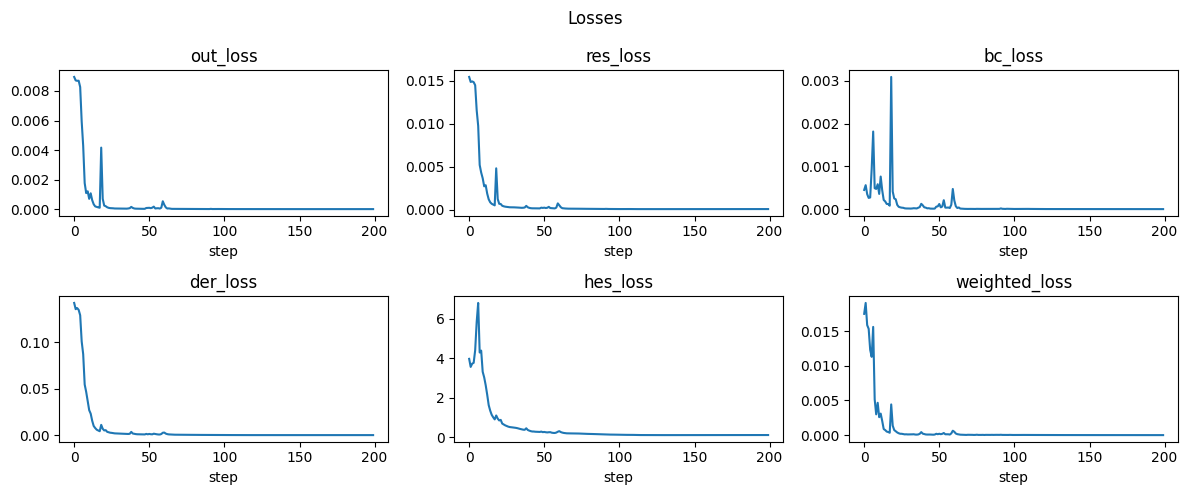


=============== Checkpoint ===============
PDE: Allen-Cahn
PDE parameters in input: ['xi1', 'xi2']
Time in input: False
Space in input: True
Fourier features: 30
|Input units|: 4
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Output+Derivative
	EWC: Off
	DWA: Norm1
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 0.8074274063110352
	IC: 1.0
	RES: 0.04004374518990517
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 0.11030110716819763
	DER: 0.042227745056152344
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importanc

In [6]:
subkeys = ["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "weighted_loss"]
if ACTION == "EWC":
    subkeys.append("ewc_loss")
        
for model_index, show in [(1, False), (2, False), (3, True)]:
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task{model_index}/models"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    plot_model_stats_grid(
        data=f"{models_dir}/trial0",
        keys=["train"],
        subkeys=subkeys,
        figsize=(12, 5),
        legend=False,
        title="Losses",
        save=SAVE_PLOTS,
        dst_file=f"{models_dir}/plots/losses.png",
        show=show
    )

    if show:
        print_model_info(f"{models_dir}/trial0")

Last bc_loss grad norm: 0.0001263810263480991
Last distill_out_loss grad norm: 0.0009209157433360815
Last distill_der_loss grad norm: 0.002408072119578719
Last res_loss grad norm: 0.0034734373912215233


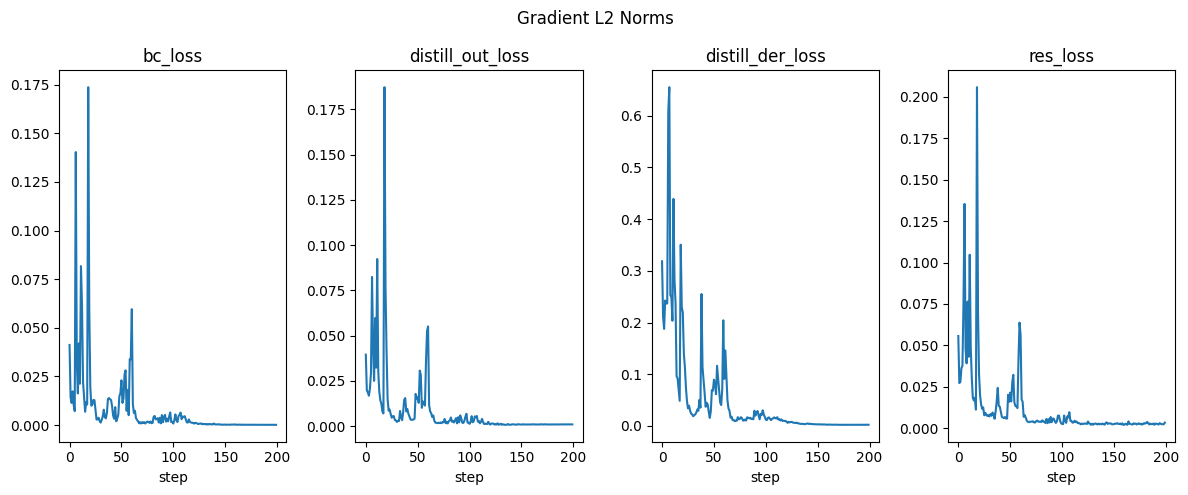

Last value weights res_loss: 0.04004374518990517
Last value weights bc_loss: 0.8074274063110352
Last value weights distill_out_loss: 0.11030110716819763
Last value weights distill_der_loss: 0.042227745056152344


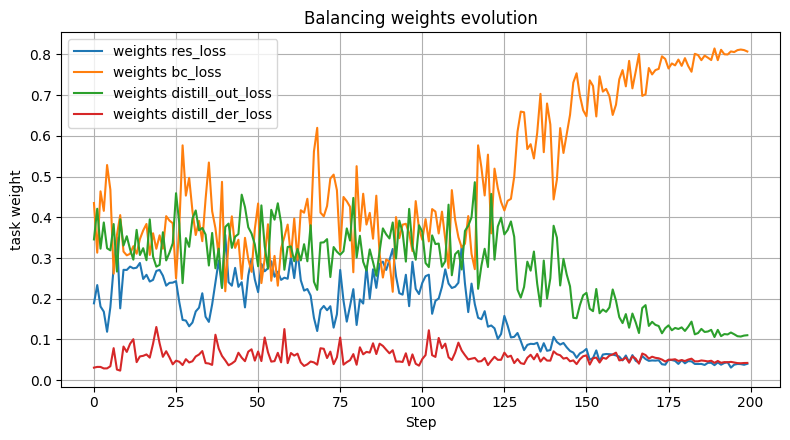

Last value conflicts bc_loss: 0.21088258922100067
Last value conflicts distill_out_loss: -0.5669570565223694
Last value conflicts distill_der_loss: -0.11127646267414093


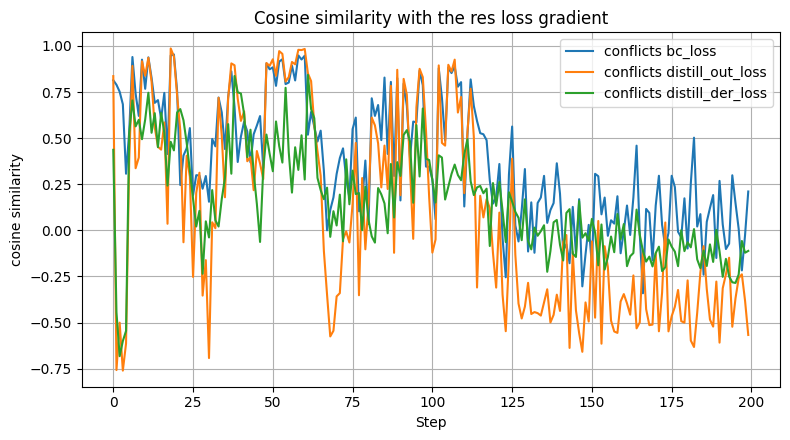

In [7]:
models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task3/models"
models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}

subkeys = ["bc_loss"]
if DISTILL:    
    items = DISTILL_MODE.split("+")
    if "Output" in items:
        subkeys.append("distill_out_loss")
    if "Derivative" in items:
        subkeys.append("distill_der_loss")
    if "Hessian" in items:
        subkeys.append("distill_hes_loss")
if REPLAY:
    subkeys.append("nl_loss")
    if REPLAY_BOUNDARY:
        subkeys.append("nl_bc_loss")

for subkey in subkeys+["res_loss"]:
    print(f"Last {subkey} grad norm: {models_dict['trial0']['grad_norms'][subkey][-1]}")

if len(subkeys) > 2:
    figsize = (12, 5)
else:
    figsize = (12, 3)
    
for model_index, show in [(1, False), (2, False), (3, True)]:
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task{model_index}/models"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    plot_model_stats_grid(
        data=f"{models_dir}/trial0",
        keys=["grad_norms"],
        subkeys=subkeys+["res_loss"],
        figsize=figsize,
        legend=False,
        title="Gradient L2 Norms",
        save=SAVE_PLOTS,
        dst_file=f"{models_dir}/plots/grad_norms.png",
        show=show
    )
    
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["weights"],
    subkeys=["res_loss"]+subkeys,
    ylabel="task weight",
    title="Balancing weights evolution",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/weights.png"
)
if EWC:
    subkeys2 = subkeys+["ewc_loss"]
else:
    subkeys2 = subkeys
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["conflicts"],
    subkeys=subkeys2,
    ylabel="cosine similarity",
    title="Cosine similarity with the res loss gradient",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/conflicts.png"
)

In [8]:
def plot_points_grid(
        dataset: str|TensorDataset,
        labels_idx: list = [1, 2, 3],
        label_names: list = [r"$u^{\theta}$", r"$\nabla_x u^{\theta}$", r"$\nabla_y u^{\theta}$"],
        points_idx: int = 0,
        subtitles: list = ["", "", ""],
        save: bool = False,
        dst_file: str = "points_grid.png",
        show: bool = True,
        cmap: str = "bwr",
        title: str = "",
        figsize: tuple = (10, 2.5),
        vmins: list = [None, None, None],
        vmaxs: list = [None, None, None]
    ) -> tuple:
    """
    Plot the dataset points values in a grid, colored according to the labels values.

    Parameters
    ----------
    dataset : str|TensorDataset
        The dataset filepath/TensorDataset object.
    labels_idx : list
        Labels column indices in the dataset.
    labels_names : list
    points_idx : int
        Spatial coordinates column index in the dataset.
    subtitles : list
    save : bool
        If True, the plot is saved.
    show : bool
        If True, the plot is showed.
    dst_file : str
        Filepath where to save the plot.
    cmap : str
    title : str
    figsize : tuple
    vmins : List[float]
    vmaxs : List[float]
    
    Returns
    -------
    tuple
        vmins, vmaxs
    """
    if type(dataset) is str:
        dataset = torch.load(dataset, weights_only=False)
    points = dataset.tensors[points_idx]
    labelss = [dataset.tensors[i] for i in labels_idx]

    font = {'size': 10}
    matplotlib.rc('font', **font)
    fig = plt.figure(figsize=figsize)
    if len(labels_idx) <= 4:
        gs = GridSpec(1, len(labels_idx), figure=fig)
        axes = [fig.add_subplot(gs[0, i]) for i in range(len(labels_idx))]
    elif len(labels_idx) <= 8:
        ncols = int(np.ceil(len(labels_idx)/2))
        gs = GridSpec(2, ncols, figure=fig)
        axes = []
        for i in range(ncols):
            axes.append(fig.add_subplot(gs[0, i]))
            axes.append(fig.add_subplot(gs[1, i]))
    else:
        raise ValueError("Too many plots.")

    for ax, labels, label_name, subtitle, vmin, vmax in zip(axes, labelss, label_names, subtitles, vmins, vmaxs):
        ax.set_title(subtitle)
        if vmin is not None and vmax is not None:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap, vmin=vmin, vmax=vmax)
        else:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap)

        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(label_name)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.plot()

    fig.suptitle(title)
    plt.tight_layout()
    if save:
        plt.savefig(dst_file)
    if show:
        plt.show()
    else:
        plt.close()
    vmins = [torch.min(labels) for labels in labelss]
    vmaxs = [torch.max(labels) for labels in labelss]

In [9]:
if CROSS_THE_RUBICON:
    for model_index in [3]:
        models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task{model_index}/models"
        os.makedirs(f"{models_dir}/plots", exist_ok=True)
        
        best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")
    
        for x_datasets, s in [(full_datasets, "full_dataset")]:
            os.makedirs(f"{models_dir}/plots/{s}", exist_ok=True)
            for i, ds in tqdm(enumerate(x_datasets[:]), total=len(x_datasets[:])):
                x = ds.datasets[0].tensors[X]
                u = ds.datasets[0].tensors[U]
                du = ds.datasets[0].tensors[DU]
                trues = [x, u, du[:, 0], du[:, 1]]
                trues = TensorDataset(*trues)
                
                labeled = compute_prediction(model=best_model, dataset=ds.datasets[0])
    
                if not os.path.exists(f"{PDE}/data/plots/{s}/true_values{i}.png"):
                    os.makedirs(f"{PDE}/data/plots/{s}", exist_ok=True)
                    true = extract_targets(dataset=ds.datasets[0])    
                    vmins, vmaxs = plot_points_grid(
                        dataset=true,
                        cmap="inferno",
                        save=True,
                        dst_file=f"{PDE}/data/plots/{s}/true_values{i}.png",
                        show=False
                    )
                    vmins = np.array(vmins)
                    vmaxs = np.array(vmaxs)
                    np.save(f"{PDE}/data/plots/{s}/vmins{i}.npy", vmins)
                    np.save(f"{PDE}/data/plots/{s}/vmaxs{i}.npy", vmaxs)
                else:
                    vmins = np.load(f"{PDE}/data/plots/{s}/vmins{i}.npy")
                    vmaxs = np.load(f"{PDE}/data/plots/{s}/vmaxs{i}.npy")
    
                plot_points_grid(
                    dataset=labeled,
                    cmap="inferno",
                    vmins=vmins,
                    vmaxs=vmaxs,
                    save=True,
                    dst_file=f"{models_dir}/plots/{s}/best_model_predictions{i}.png",
                    show=False
                );

                plot_points_grid(
                    dataset=trues,
                    cmap="inferno",
                    label_names=[r"$u$", r"$\nabla_x u$", r"$\nabla_y u$"],
                    vmins=vmins,
                    vmaxs=vmaxs,
                    save=SAVE_PLOTS,
                    dst_file=f"{models_dir}/plots/{s}/true_predictions{i}.png",
                    show=False
                );
    
                differences = compute_prediction_difference(model=best_model, dataset=ds.datasets[0])
                #vmins = len(differences)*[min([t.min() for t in differences.tensors[1:]])]
                #vmaxs = len(differences)*[max([t.max() for t in differences.tensors[1:]])]
                #plot_points_grid(
                #    dataset=differences,
                    #vmins=vmins,
                    #vmaxs=vmaxs,
                #    save=True,
                #    dst_file=f"{models_dir}/plots/{s}/differences{i}.png",
                #    show=False
                #);
            
                vmin_u = max([t.min() for t in differences.tensors[1]])
                vmin_dux = max([t.min() for t in differences.tensors[2]])
                vmin_duy = max([t.min() for t in differences.tensors[3]])

                vmax_u = max([t.max() for t in differences.tensors[1]])
                vmax_dux = max([t.max() for t in differences.tensors[2]])
                vmax_duy = max([t.max() for t in differences.tensors[3]])

                v_diff_u = max(abs(vmin_u), abs(vmax_u))
                v_diff_dux = max(abs(vmin_dux), abs(vmax_dux))
                v_diff_duy = max(abs(vmin_duy), abs(vmax_duy))

                vmins = [-v_diff_u, -v_diff_dux, -v_diff_duy]
                vmaxs = [v_diff_u, v_diff_dux, v_diff_duy]
                
                plot_points_grid(
                    dataset=differences,
                    vmins=vmins,
                    vmaxs=vmaxs,
                    label_names=[r"$u^{\theta} - u$", r"$\nabla_x u^{\theta} - \nabla_x u$", r"$\nabla_y u^{\theta} - \nabla_y u$"],
                    save=SAVE_PLOTS,
                    dst_file=f"{models_dir}/plots/{s}/differences{i}.png",
                    show=False
                );
    
            print(f"{s} predictions saved.")

100%|██████████| 20/20 [02:02<00:00,  6.13s/it]

full_dataset predictions saved.


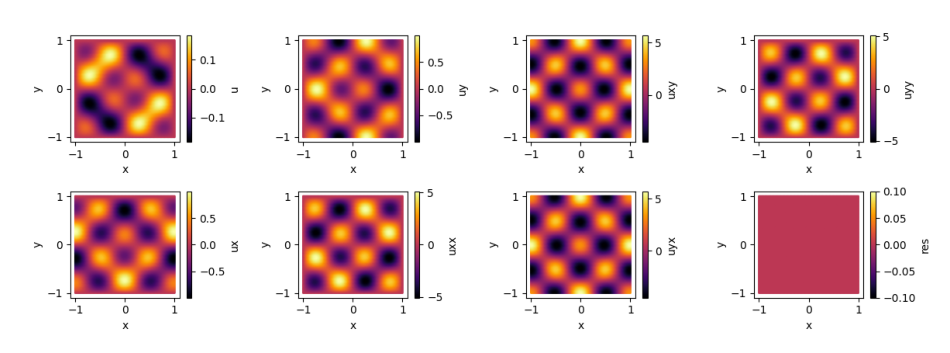

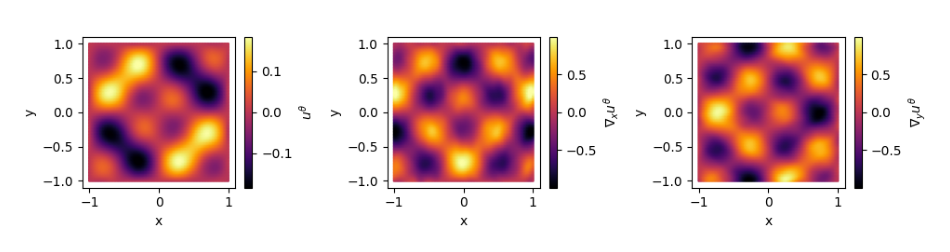

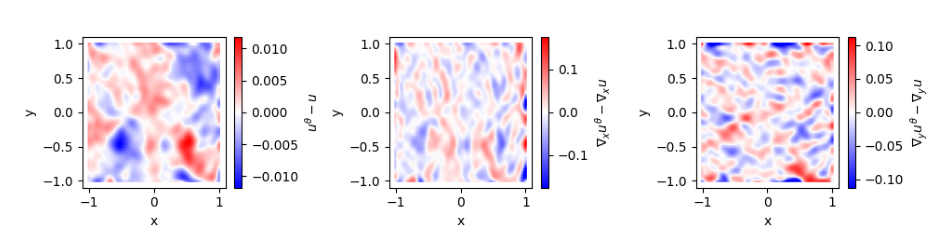

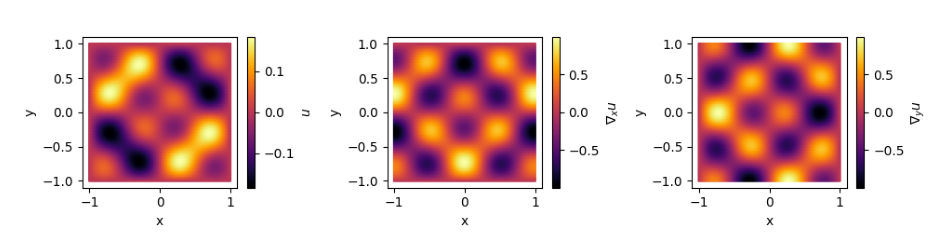

-------------------------------------------


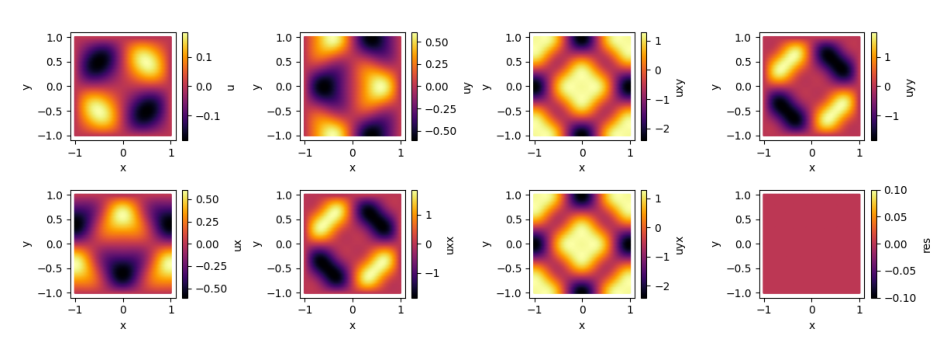

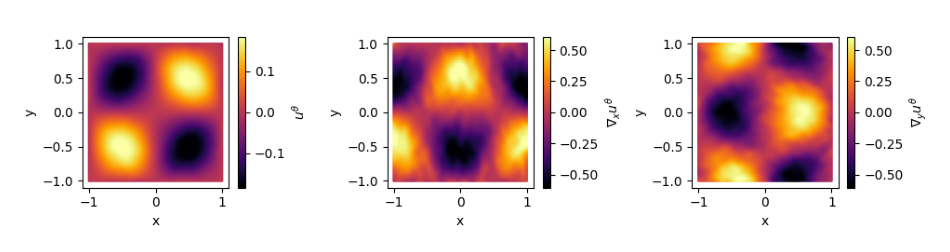

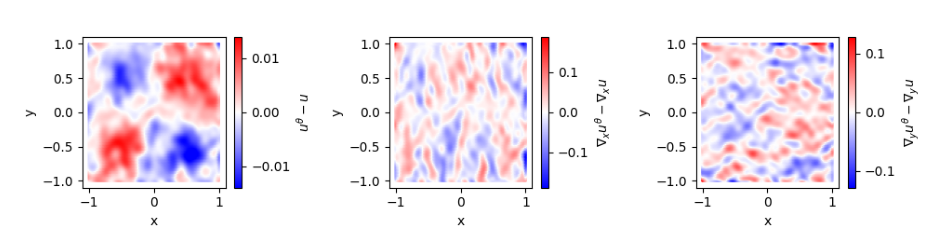

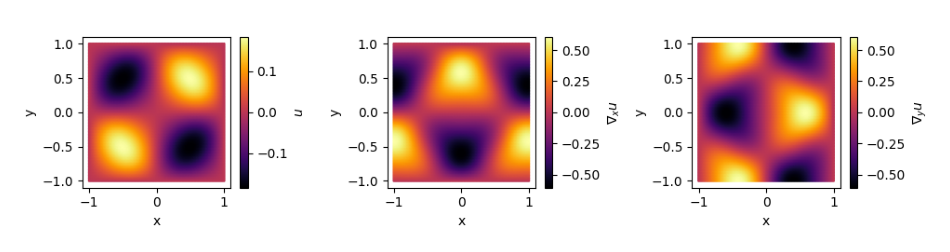

-------------------------------------------


In [10]:
if CROSS_THE_RUBICON:    
    model_index = 3
    to_show = [0, 19]

    dataset_name = "full_dataset"

    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task{model_index}/models"
    dataset_name = "full_dataset"

    for i in to_show:
        img = mpimg.imread(f"{PDE}/data/plots/{dataset_name}/true_values{i}.png")
        plt.figure(figsize=(12, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        for img_name in [f"best_model_predictions{i}", f"differences{i}", f"true_predictions{i}"]:
            img = mpimg.imread(f"{models_dir}/plots/{dataset_name}/{img_name}.png")
            plt.figure(figsize=(12, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        print("-------------------------------------------")

In [11]:
if CROSS_THE_RUBICON:    
    models_dirs = [
        f"{PDE}/FullDomainLearning/MultiTask/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS_TASK0}/models2",
        f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task0_{N_EPOCHS_TASK0}/models2"
    ] + [f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task{model_index}/models" for model_index in [1, 2, 3]]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    models_names = ["Mfull", "M0", "M1", "M2", "M3"]

    for datasets, name, dst in zip([train_datas, intra_test_datas], ["train", "intra_test"], ["train_dataset", "intra_test_dataset"]):
        for i, dataset in tqdm(enumerate(datasets), total=len(datasets)):
            os.makedirs(f"{models_dirs[-1]}/plots/{dst}", exist_ok=True)
            dst_file = [f"{models_dirs[-1]}/plots/{dst}/models_comparison_task{i}.png"]

            plot_performance_comparison(
                models=models,
                models_names=models_names,
                datasets=[dataset],
                datasets_names=[f"{name}{i}"],
                subset={"x": [-1.0, 1.0], "y": [-1.0, 1.0]},
                figsize=(9, 2.5),
                save=True,
                dst_files=dst_file,
                show=False
            )

100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


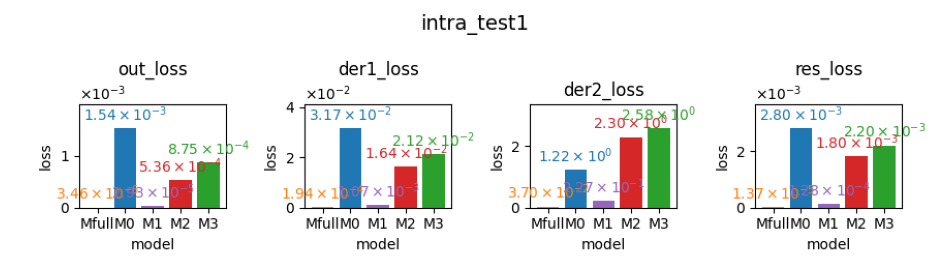

In [12]:
if CROSS_THE_RUBICON:    
    task = 1
    dataset_name = "intra_test_dataset"

    models_dir = f"./{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task3/models"
    img_file = f"{models_dir}/plots/{dataset_name}/models_comparison_task{task}.png"
    img = mpimg.imread(img_file)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [13]:
for model_index in [1, 2, 3]:
    models_dirs = [
        f"{PDE}/FullDomainLearning/MultiTask/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS_TASK0}/models2",
        f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task{model_index}/models"
    ]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    models_names = ["Mfull", f"M{model_index}"]
    
    for datasets, name, dst in zip([train_datas, intra_test_datas, [inter_test_data]], 
                                   ["train", "intra_test", "inter_test"], 
                                   ["train_dataset", "intra_test_dataset", "inter_test_dataset"]
                                   ):
        for i, dataset in tqdm(enumerate(datasets), total=len(datasets)):
            os.makedirs(f"{models_dirs[-1]}/plots/{dst}", exist_ok=True)
            dst_file = [f"{models_dirs[-1]}/plots/{dst}/full_comparison_task{i}.png"]

            plot_performance_comparison(
                models=models,
                models_names=models_names,
                datasets=[dataset],
                datasets_names=[f"{name}{i}"],
                subset={"x": [-1.0, 1.0], "y": [-1.0, 1.0]},
                figsize=(11, 3),
                bar_labels=True,
                yaxis_visible=True,
                colors=["firebrick", "tab:blue"],
                save=SAVE_PLOTS,
                dst_files=dst_file,
                show=False
            )
    
    datasets = [prepare_dataset(intra_test_datasets), inter_test_data]
    names = ["intra_test", "inter_test"]
    dst_files = [f"{models_dirs[-1]}/plots/intra_test_dataset/full_comparison_allTasks.png", f"{models_dirs[-1]}/plots/inter_test_dataset/full_comparison_allTasks.png"]

    plot_performance_comparison(
        models=models,
        models_names=models_names,
        datasets=datasets,
        datasets_names=names,
        subset={"x": [-1.0, 1.0], "y": [-1.0, 1.0]},
        figsize=(11, 3),
        bar_labels=True,
        yaxis_visible=True,
        colors=["firebrick", "tab:blue"],
        save=SAVE_PLOTS,
        dst_files=dst_files,
        show=False
    )

100%|██████████| 1/1 [00:00<00:00,  1.20it/s]


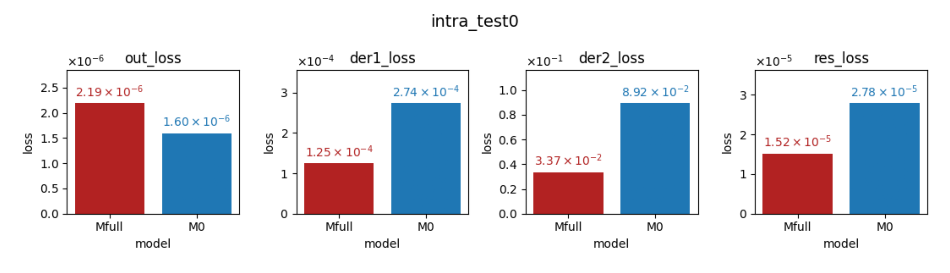

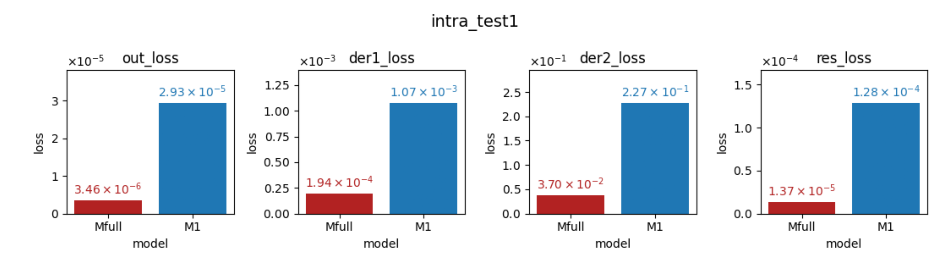

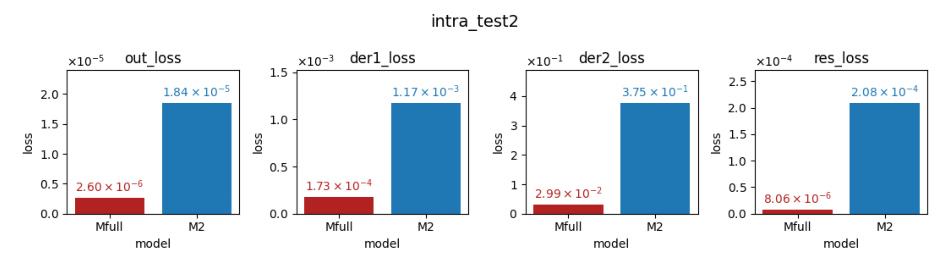

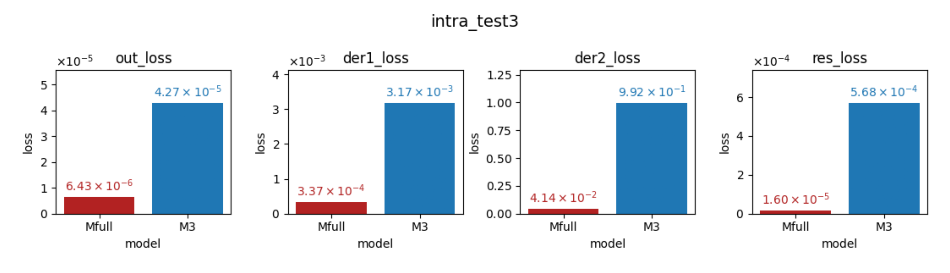

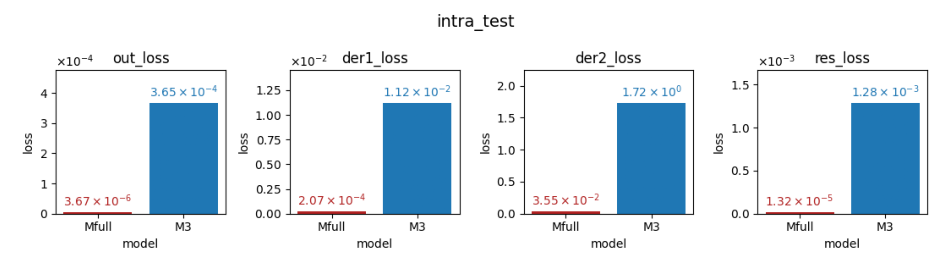

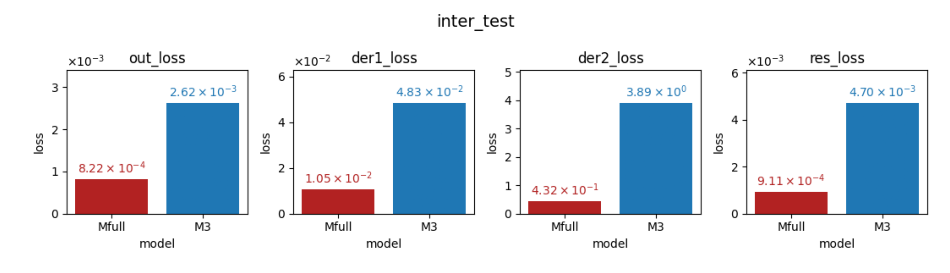

In [14]:
dataset_name = "intra_test_dataset"

models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task0_{N_EPOCHS_TASK0}/models2"
img_file = f"{models_dir}/plots/{dataset_name}0.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

for i in [1, 2, 3]:
    models_dir = f"./{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task{i}/models"
    img_file = f"{models_dir}/plots/{dataset_name}/full_comparison_task{i}.png"
    img = mpimg.imread(img_file)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

models_dir = f"./{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task3/models"
img_file = f"{models_dir}/plots/{dataset_name}/full_comparison_allTasks.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

dataset_name = "inter_test_dataset"

models_dir = f"./{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/{FOLDER}/Task3/models"
img_file = f"{models_dir}/plots/{dataset_name}/full_comparison_allTasks.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
if CLIP_GRAD == False:
    subsets = [{"x": [-1.0, 1.0], "y": [-1.0, 1.0]}]

    models_dirs = [
        f"./{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_GradClip/{FOLDER}/Task3/models"
        f"./{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_NoGradClip/{FOLDER}/Task3/models"
        ]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    models_names = [f"GradClip", f"NoGradClip"]

    datasets = [prepare_dataset(intra_test_datasets)]

    for i, subset in enumerate(subsets):
        datasets_names = ["intra_test"]
        datasets_names = [f"{s} - subset {i}" for s in datasets_names]

        dst_files = ["intra_test_dataset"]
        for s in dst_files:
            os.makedirs(f"{models_dirs[0]}/plots/{s}", exist_ok=True)
        dst_files = [f"{models_dirs[0]}/plots/{s}/clip_grad_or_not_subset{i}.png" for s in dst_files]

        plot_performance_comparison(
            models=models,
            models_names=models_names,
            datasets=datasets,
            datasets_names=datasets_names,
            subset=subset,
            figsize=(11, 3),
            bar_labels=True,
            yaxis_visible=True,
            colors=["firebrick", "tab:blue"],
            save=SAVE_PLOTS,
            dst_files=dst_files,
            show=True
        )

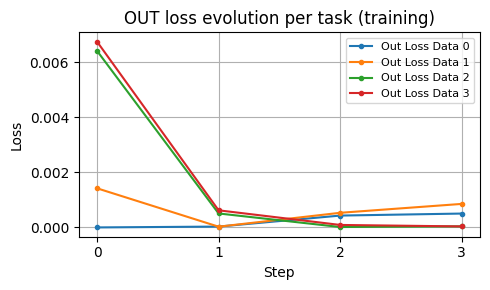

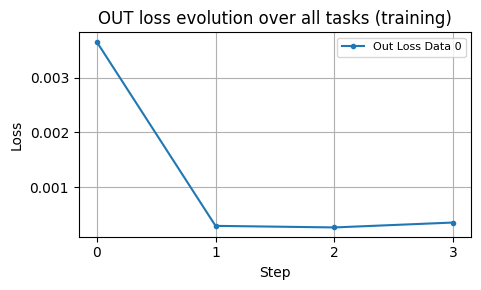

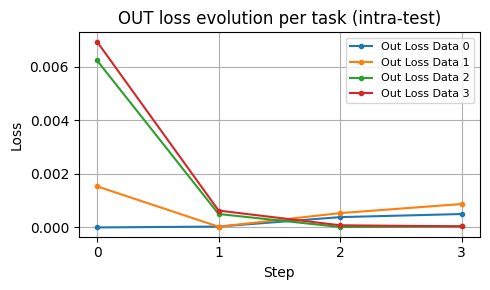

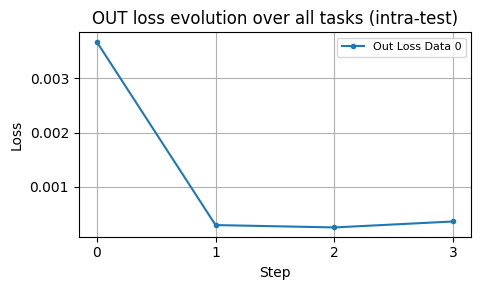

In [16]:
prefix = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}"

models = [f"{prefix}/Task0_{N_EPOCHS_TASK0}/models2/trial0/model.pth"] + \
    [f"{prefix}/{FOLDER}/Task{task}/models/trial0/model.pth" for task in [1, 2, 3]]

datass = [
    [extract_TensorDataset(prepare_dataset(train_task[task])) for task in [0, 1 , 2, 3]],
    [extract_TensorDataset(prepare_dataset(train_datasets))],
    [extract_TensorDataset(prepare_dataset(intra_test_task[task])) for task in [0, 1 , 2, 3]],
    [extract_TensorDataset(prepare_dataset(intra_test_datasets))]
]

title_start = "OUT loss evolution"
titles = [
    title_start + " per task (training)",
    title_start + " over all tasks (training)",
    title_start + " per task (intra-test)",
    title_start + " over all tasks (intra-test)"
]
filenames = [
    "train_out_loss_per_task",
    "train_out_loss_all_tasks",
    "intra_test_out_loss_per_task",
    "intra_test_out_loss_all_tasks"
]

plot_dir = f"{prefix}/{FOLDER}/ForgetPlots"
os.makedirs(plot_dir, exist_ok=True)
for datas, title, filename in zip(datass, titles, filenames):
    plot_loss(
        model_sequence=models,
        losses=["out"],
        data_sequence=datas,
        title=title,
        save=True,
        dst_file=f"{plot_dir}/{filename}.png",
        figsize=(5, 3),
        legend_fontsize=8
    )